In [263]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import contractions
import numpy as np
from sklearn.utils import resample

In [242]:
blacklist = ['askreddit', 'showerthoughts', 'psychology', 'addiction']

In [243]:
full_df = pd.DataFrame()
for dir in os.listdir('.'):
    if dir.endswith('.csv') and 'full' not in dir and dir.replace(".csv", "") not in blacklist:
        df = pd.read_csv(dir)
        full_df = pd.concat([full_df, df], ignore_index=True)

full_df = full_df.fillna('')
full_df['title_length'] = full_df['title'].apply(lambda x: len(x.split()))
full_df['selftext_length'] = full_df['selftext'].apply(lambda x: len(x.split()))

# Experimenting with downsampling r/teenagers

In [297]:
teen_df = full_df[full_df["subreddit"] == "teenagers"]
teen_downsampled = teen_df.sample(frac=0.6, random_state=42)

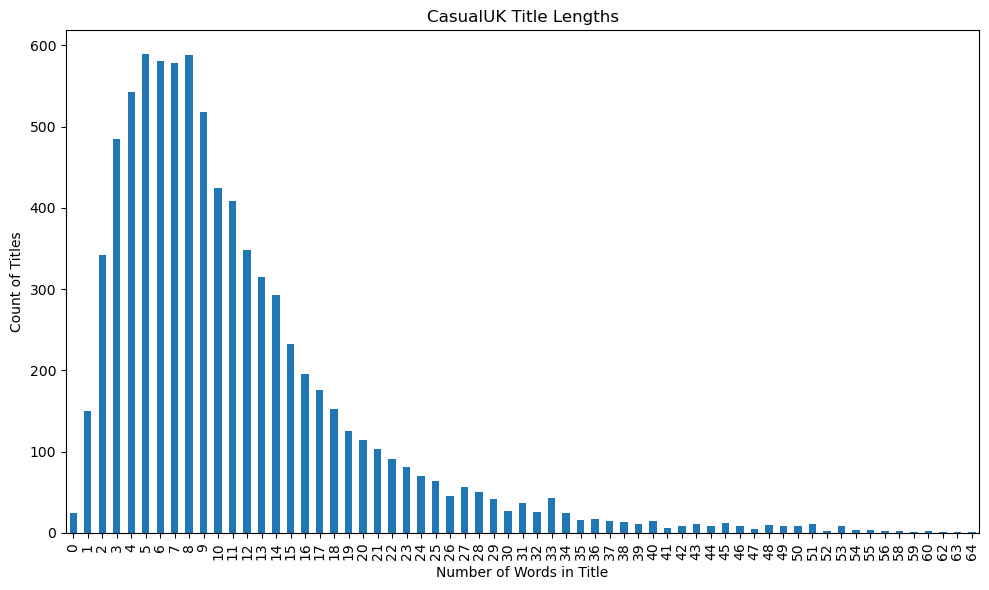

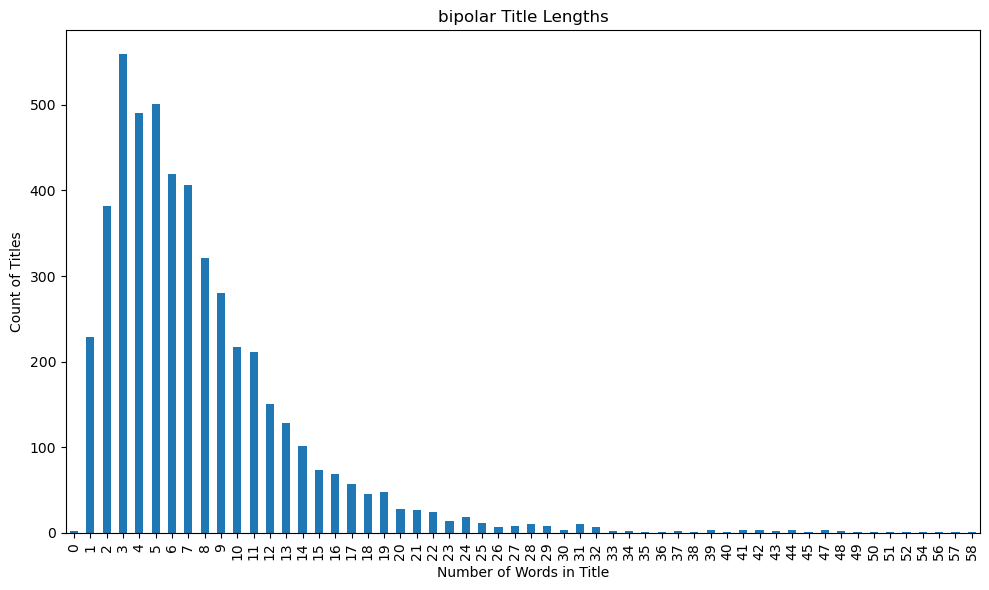

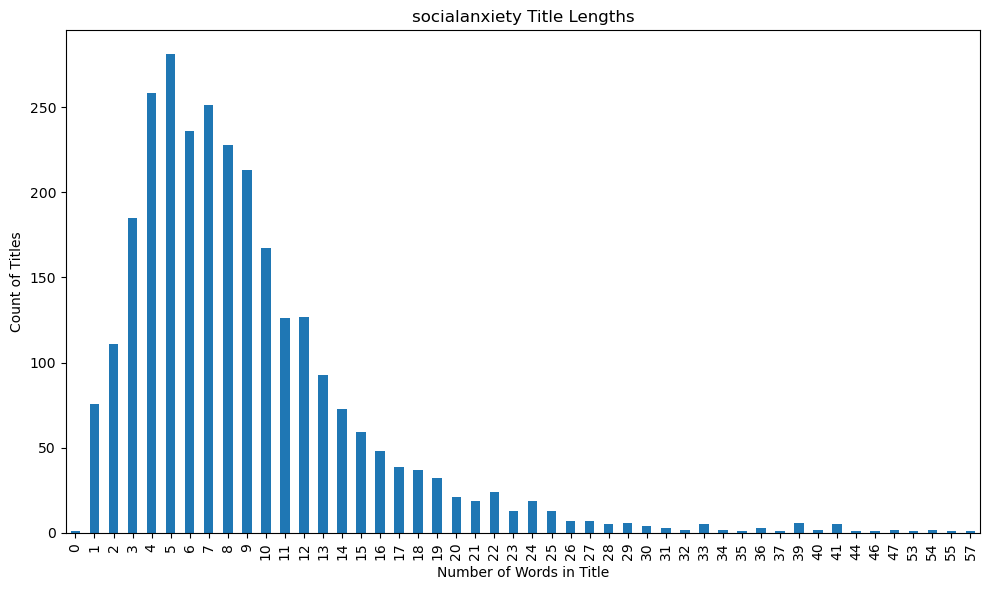

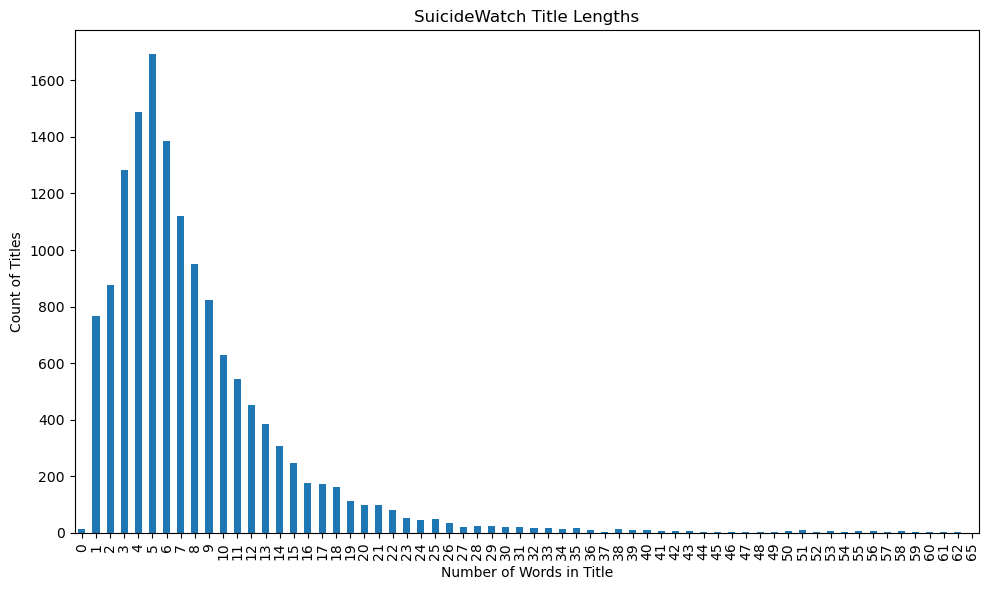

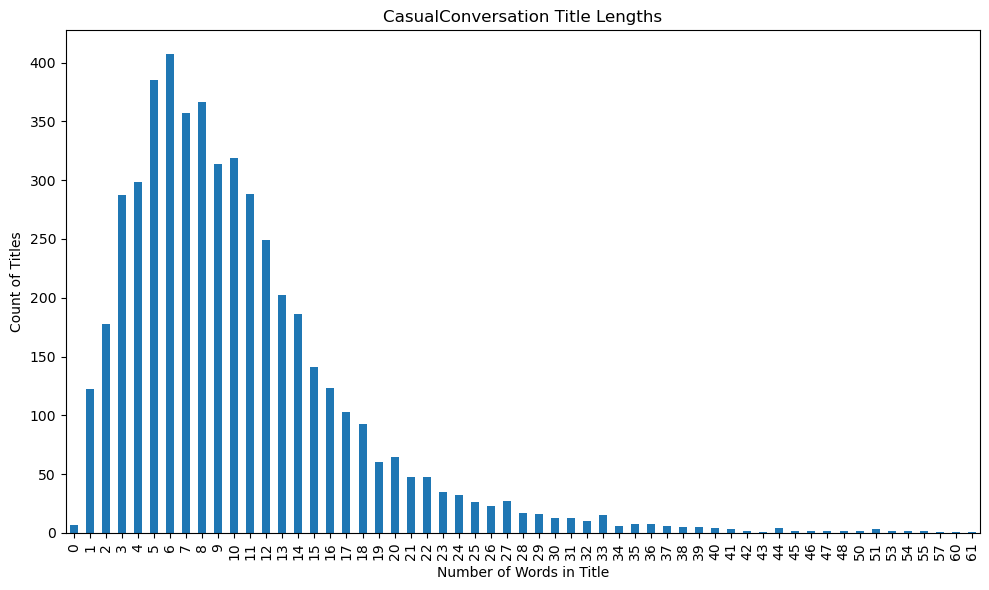

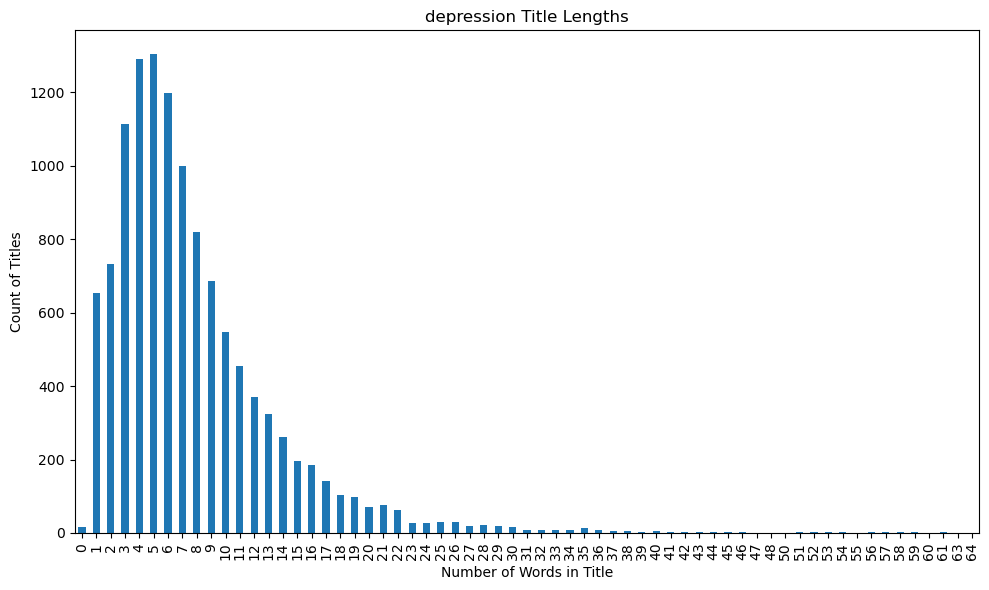

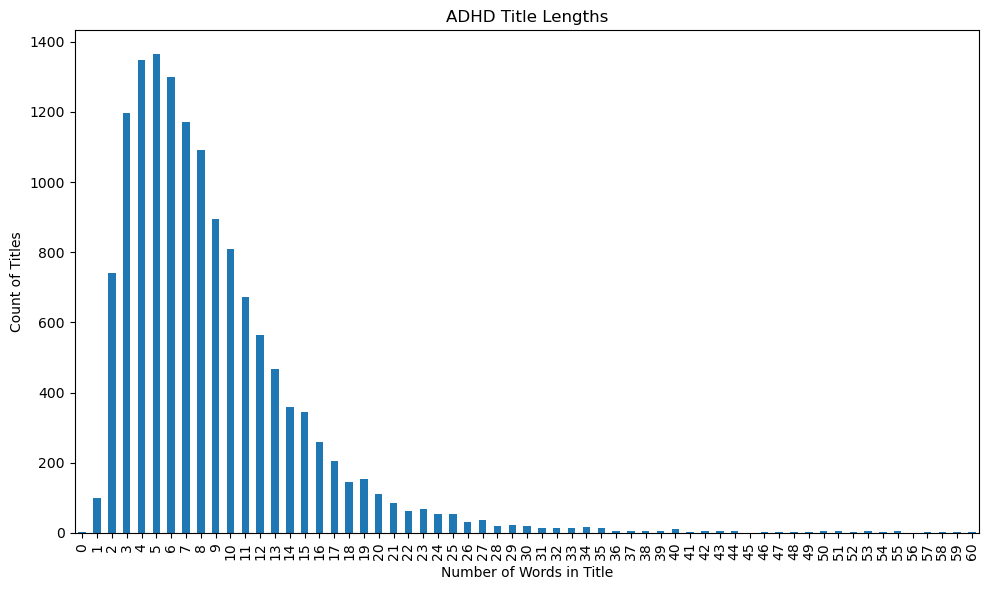

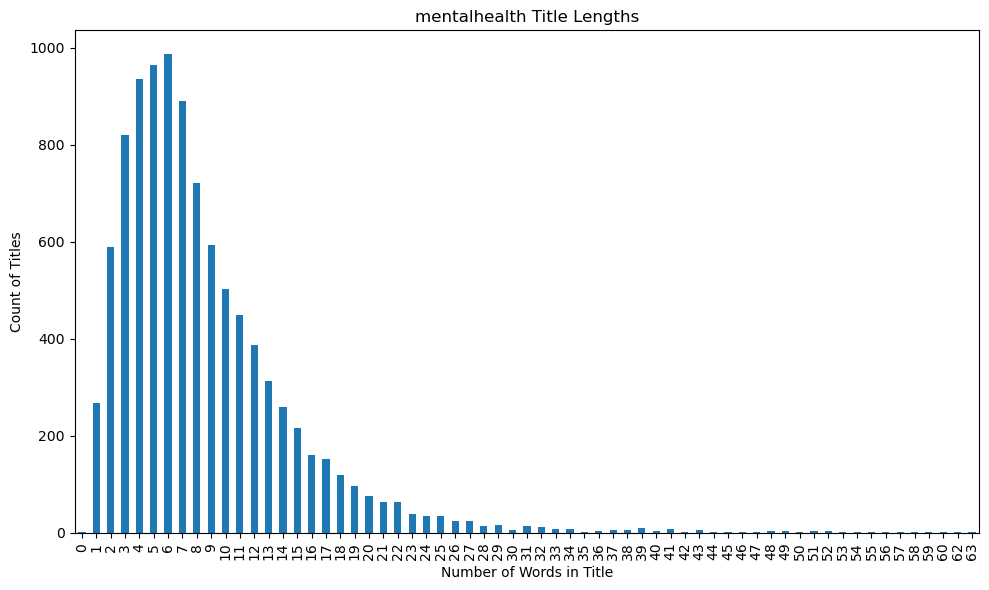

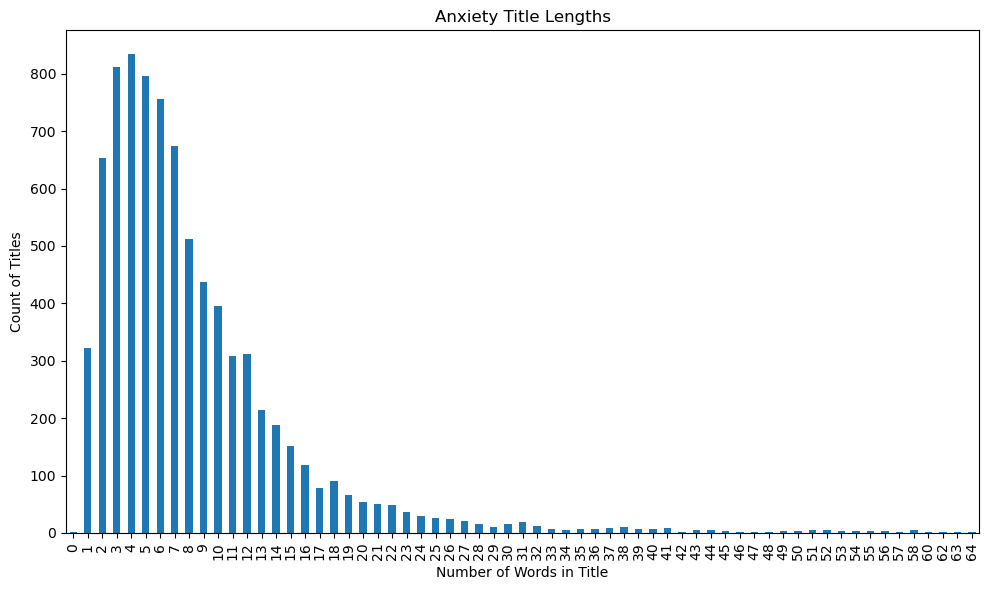

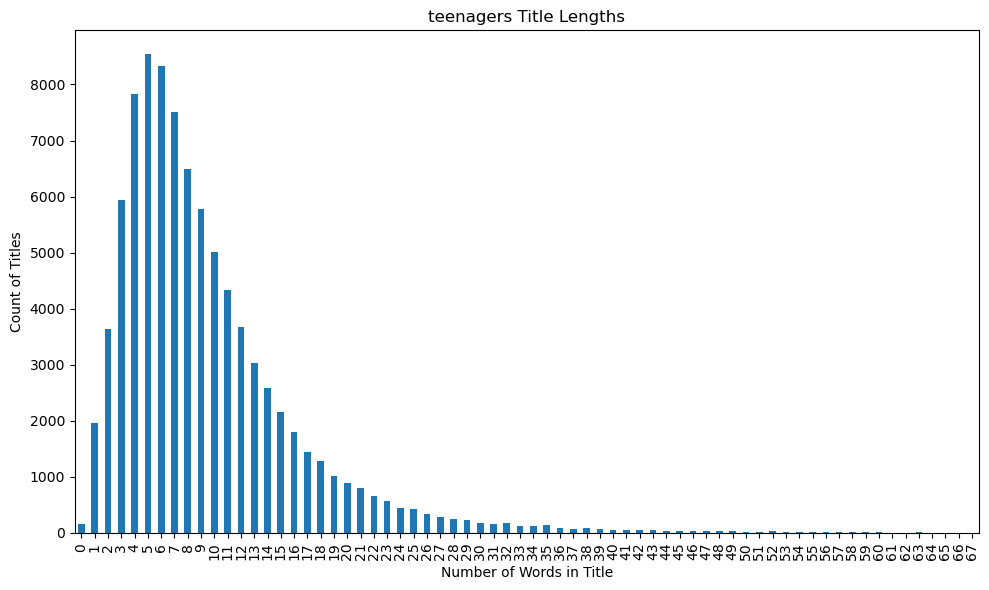

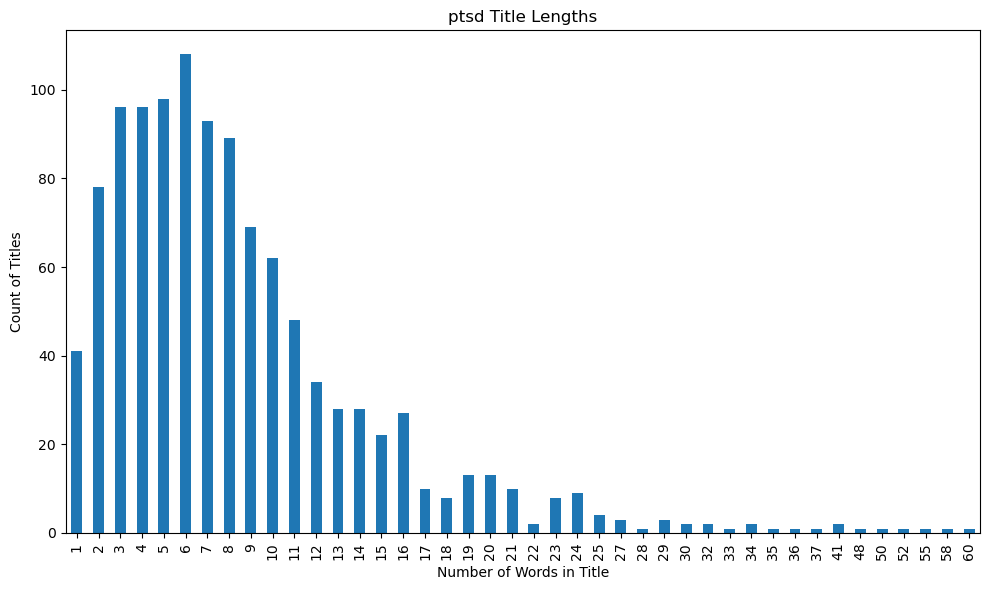

In [244]:
for subreddit in full_df['subreddit'].unique():
    subreddit_df = full_df[full_df['subreddit'] == subreddit].copy()
    subreddit_df['title_length'].value_counts().sort_index().plot(
        kind='bar',
        title=f'{subreddit} Title Lengths',
        xlabel='Number of Words in Title',
        ylabel='Count of Titles',
        figsize=(10, 6)
    )
    plt.tight_layout()
    plt.show()


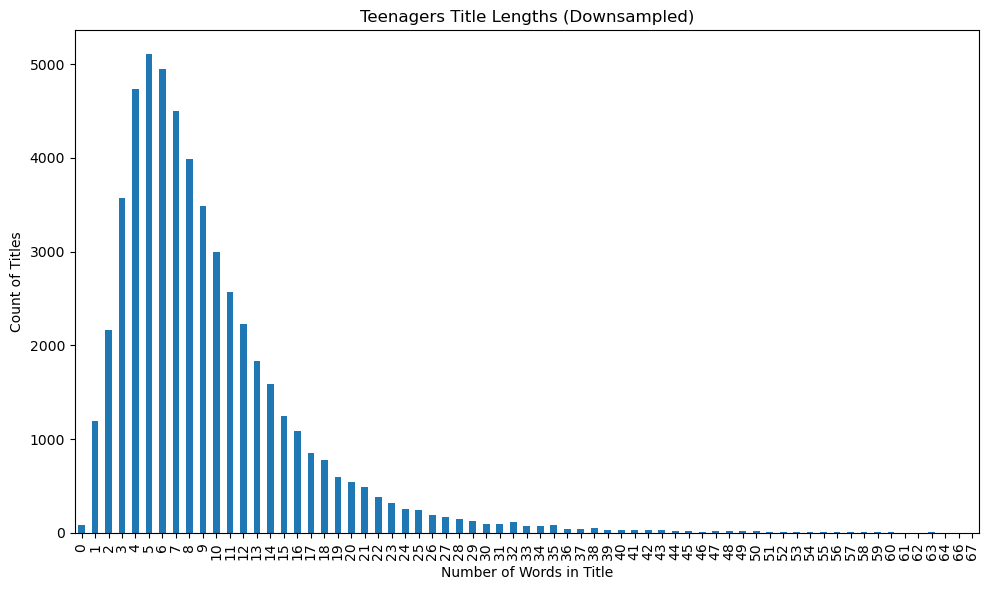

In [298]:
# Plot same graph for downsampled teenagers
teen_downsampled['title_length'].value_counts().sort_index().plot(
    kind='bar',
    title='Teenagers Title Lengths (Downsampled)',
    xlabel='Number of Words in Title',
    ylabel='Count of Titles',
    figsize=(10, 6)
)
plt.tight_layout()
plt.show()


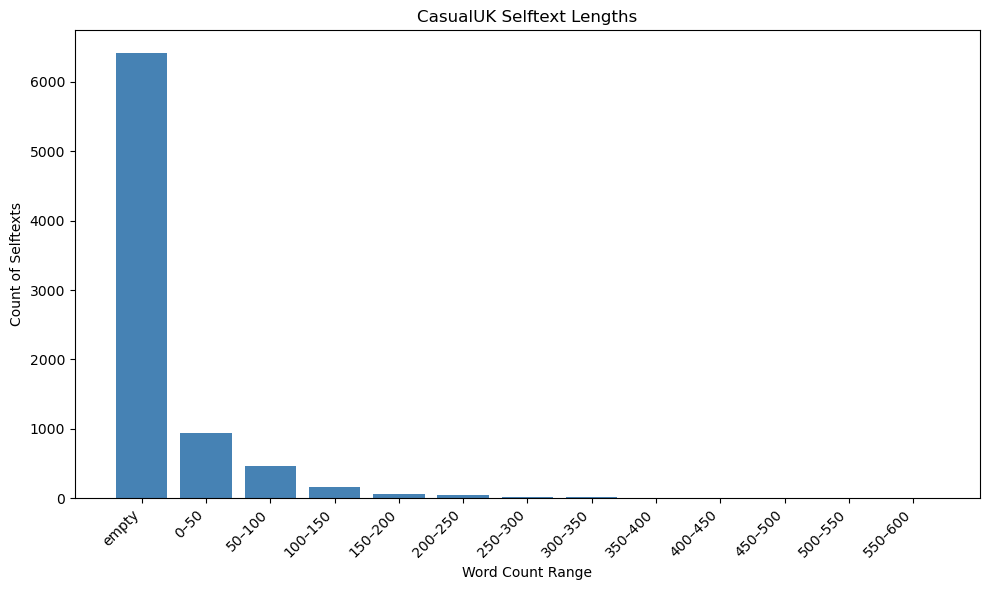

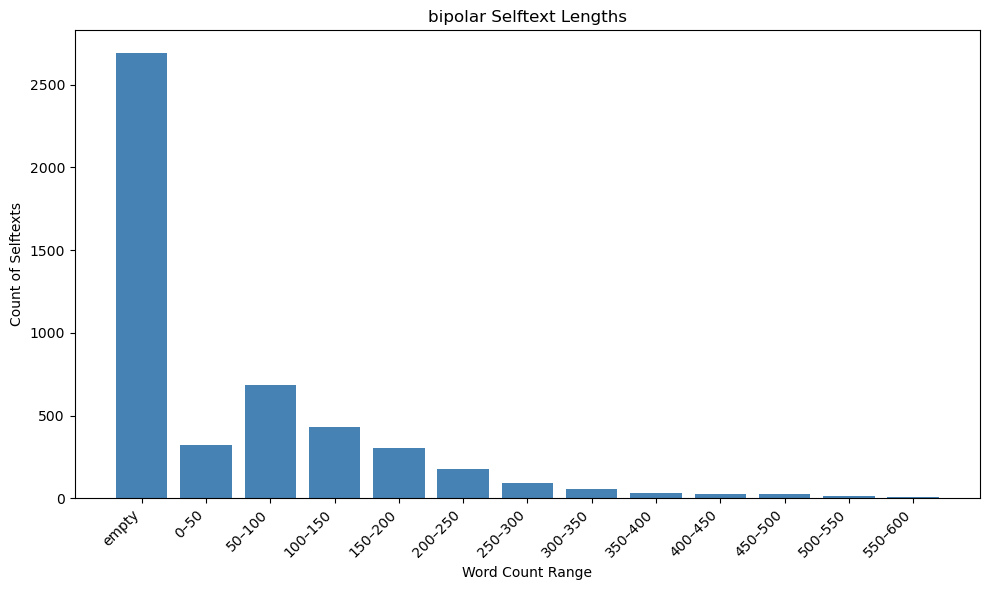

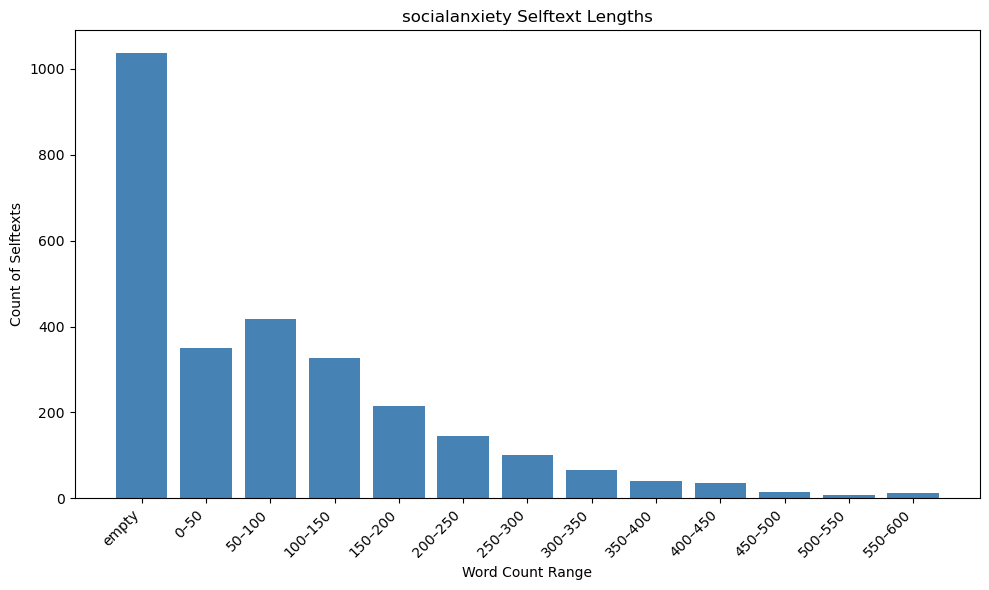

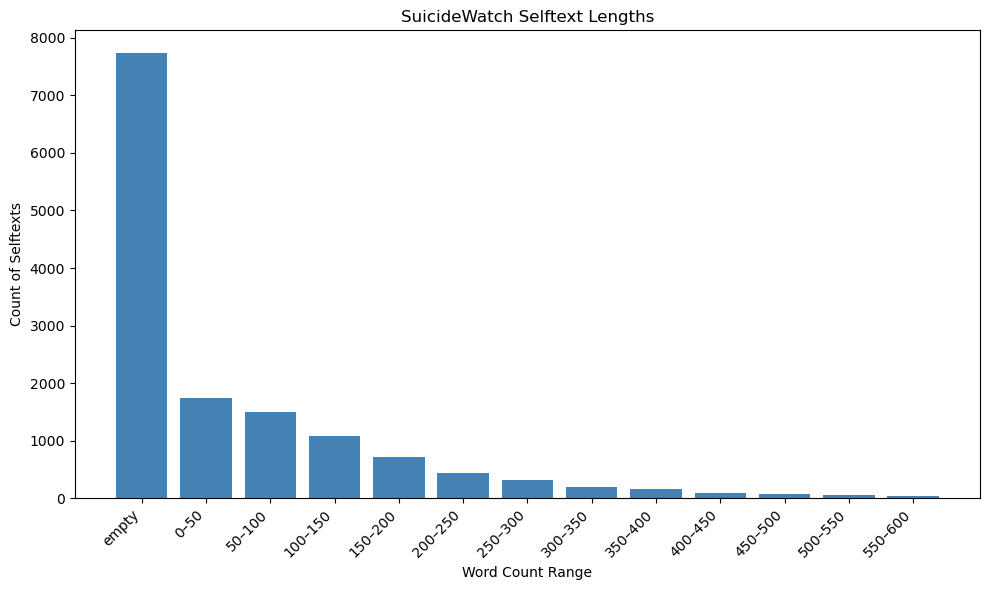

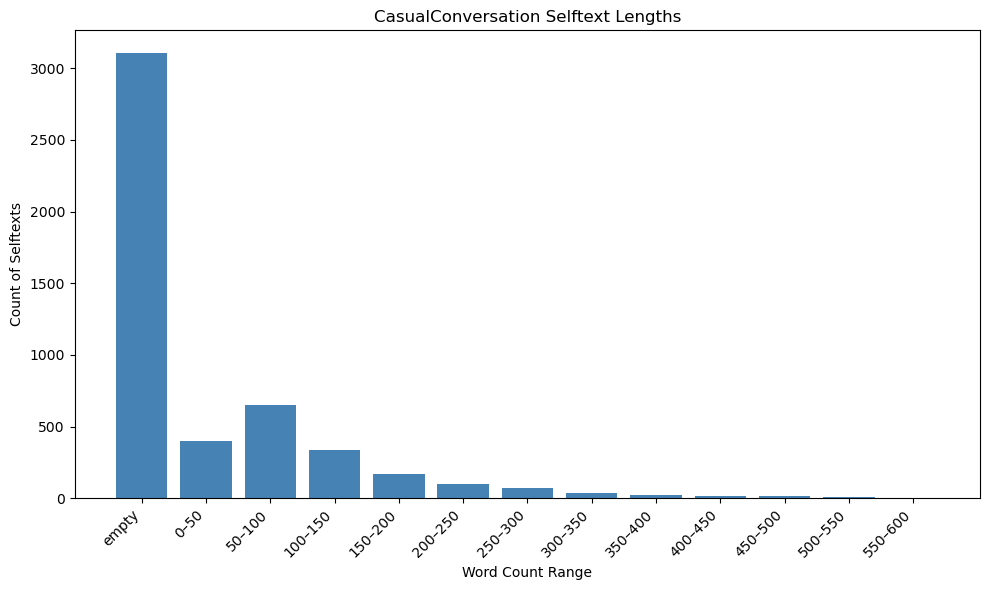

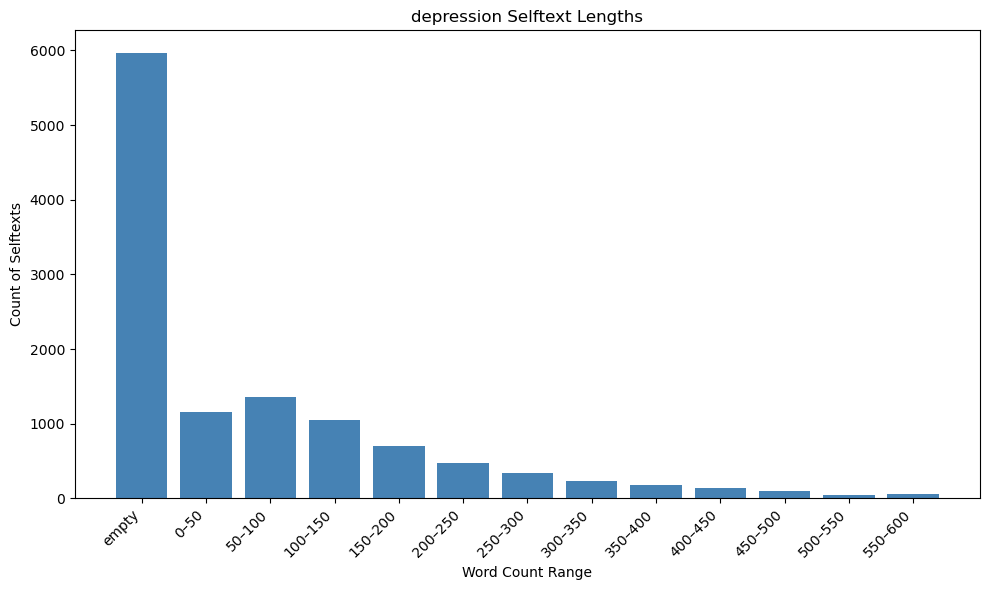

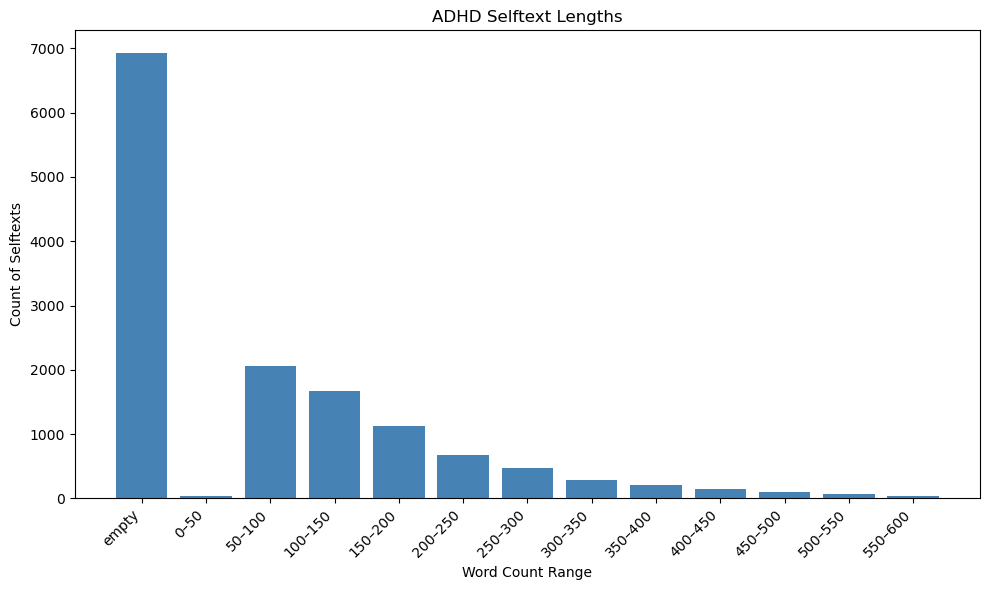

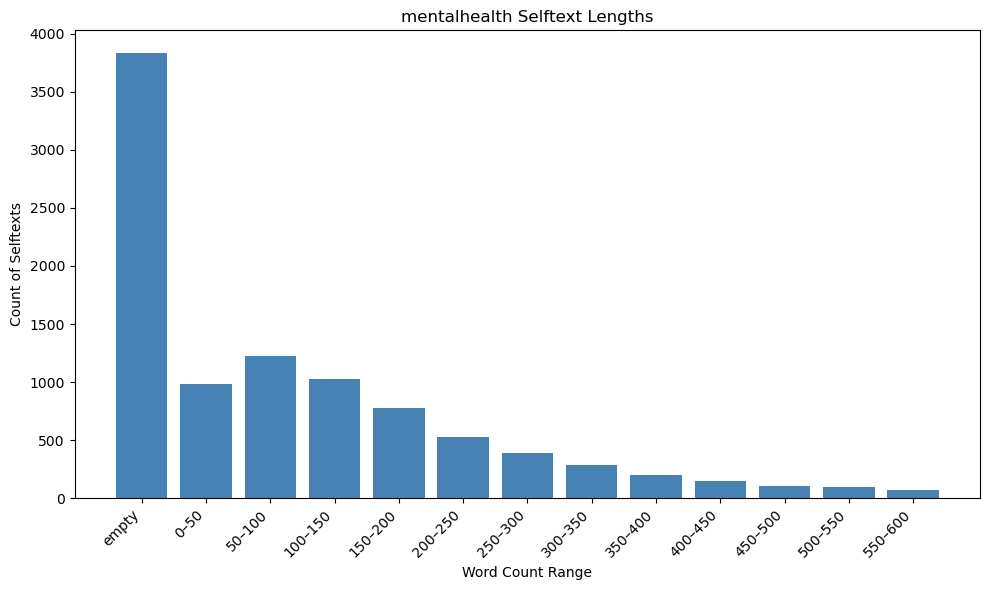

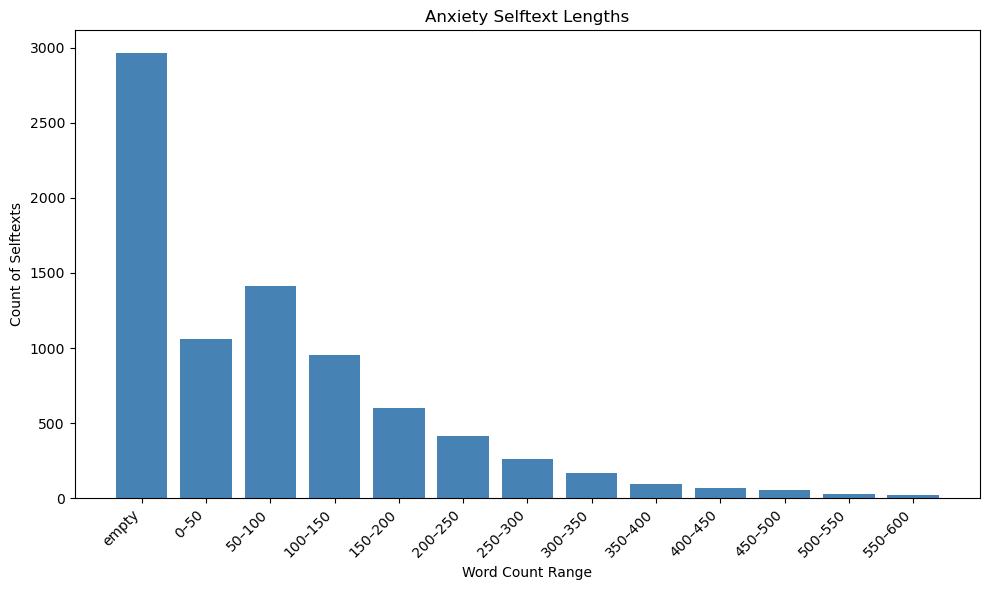

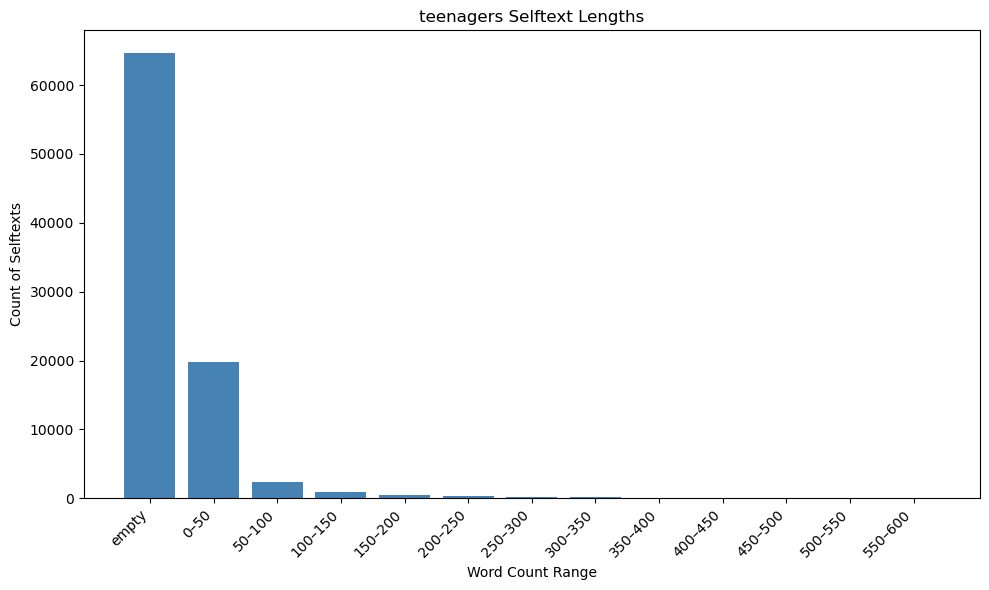

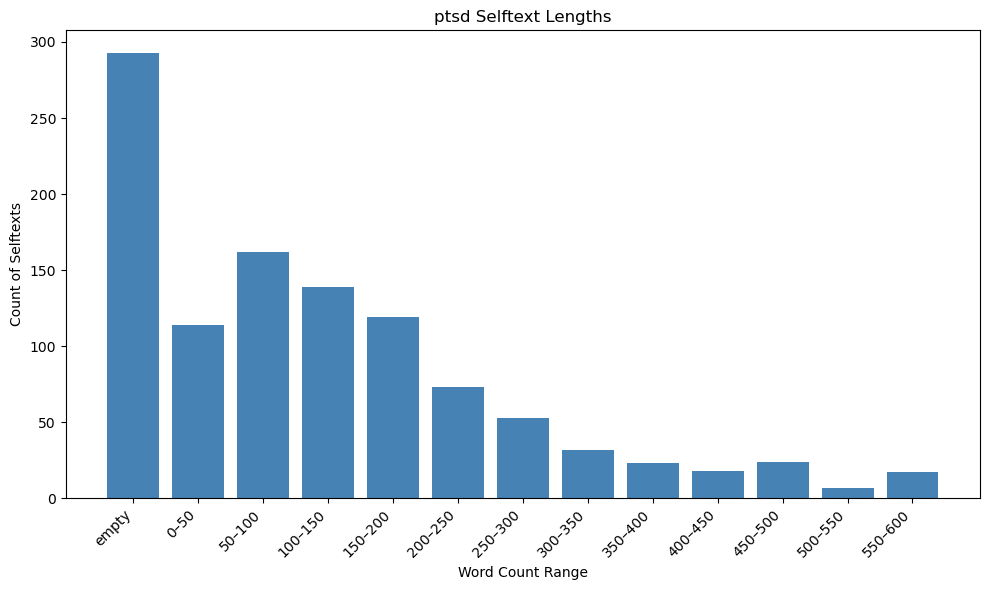

In [ ]:
for subreddit in full_df['subreddit'].unique():
    subreddit_df = full_df[full_df['subreddit'] == subreddit].copy()
    subreddit_df['length_for_bin'] = subreddit_df['selftext_length'].replace(0, -1)
    bins = [-2, -0.5] + list(np.arange(0, 650, 50))
    subreddit_df['length_bin'] = pd.cut(subreddit_df['length_for_bin'], bins=bins)
    counts = subreddit_df['length_bin'].value_counts().sort_index()
    labels = []
    for interval in counts.index:
        if interval.left < 0:
            labels.append('empty')
        else:
            labels.append(f'{int(interval.left)}–{int(interval.right)}')
    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts.values, color='steelblue')
    plt.title(f'{subreddit} Selftext Lengths')
    plt.xlabel('Word Count Range')
    plt.ylabel('Count of Selftexts')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


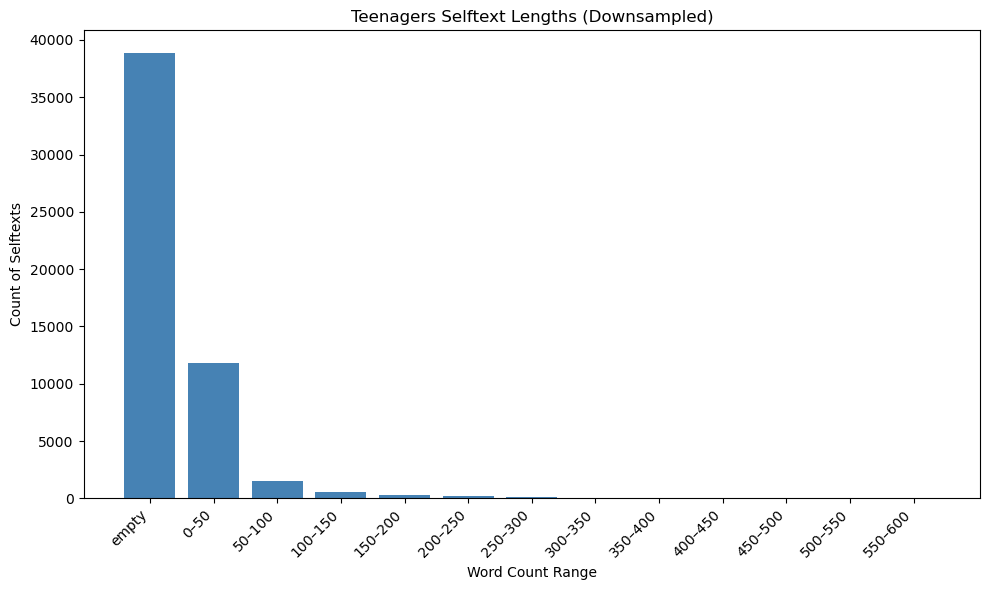

In [299]:
# Plot same graph for downsampled teenagers for selftext lengths
teen_downsampled['length_for_bin'] = teen_downsampled['selftext_length'].replace(0, -1)
bins = [-2, -0.5] + list(np.arange(0, 650, 50))
teen_downsampled['length_bin'] = pd.cut(teen_downsampled['length_for_bin'], bins=bins)
counts = teen_downsampled['length_bin'].value_counts().sort_index()
labels = []
for interval in counts.index:
    if interval.left < 0:
        labels.append('empty')
    else:
        labels.append(f'{int(interval.left)}–{int(interval.right)}')
plt.figure(figsize=(10, 6))
plt.bar(labels, counts.values, color='steelblue')
plt.title('Teenagers Selftext Lengths (Downsampled)')
plt.xlabel('Word Count Range')
plt.ylabel('Count of Selftexts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [300]:
subreddits = full_df['subreddit'].unique()
print(f"Subreddits included: {', '.join(subreddits)}")
print(f"Total rows after filtering: {len(full_df)}")
for subreddit in subreddits:
    subreddit_df = full_df[full_df['subreddit'] == subreddit]
    print(f"{subreddit}: {len(subreddit_df)} rows")
print(f"Teenagers downsampled: {len(teen_downsampled)} rows")

Subreddits included: CasualUK, bipolar, socialanxiety, SuicideWatch, CasualConversation, depression, ADHD, mentalhealth, Anxiety, teenagers, ptsd
Total rows after filtering: 169732
CasualUK: 8158 rows
bipolar: 4910 rows
socialanxiety: 2818 rows
SuicideWatch: 14382 rows
CasualConversation: 4947 rows
depression: 12016 rows
ADHD: 13935 rows
mentalhealth: 9979 rows
Anxiety: 8216 rows
teenagers: 89252 rows
ptsd: 1119 rows
Teenagers downsampled: 53551 rows


In [301]:
mentalhealth = full_df[(full_df['subreddit'] == 'ADHD') |
                       (full_df['subreddit'] == 'Anxiety') |
                       (full_df['subreddit'] == 'SuicideWatch') |
                       (full_df['subreddit'] == 'mentalhealth') |
                       (full_df['subreddit'] == 'depression') |
                       (full_df['subreddit'] == 'bipolar') |
                       (full_df['subreddit'] == 'ptsd') |
                       (full_df['subreddit'] == 'socialanxiety')]
# Make sure teen downsampled is included in normal
normal = full_df[(full_df['subreddit'] == 'CasualUK') |
                 (full_df['subreddit'] == 'CasualConversation')]
normal = pd.concat([normal, teen_downsampled], ignore_index=True)
mentalhealth = mentalhealth[~((mentalhealth['title'] == '') & (mentalhealth['selftext'] == ''))]
normal = normal[~((normal['title'] == '') & (normal['selftext'] == ''))]
mentalhealth_count = mentalhealth.shape[0]
normal_count = normal.shape[0]
print(f"Mental health posts: {mentalhealth_count}")
print(f"Normal posts: {normal_count}")

Mental health posts: 67349
Normal posts: 66535


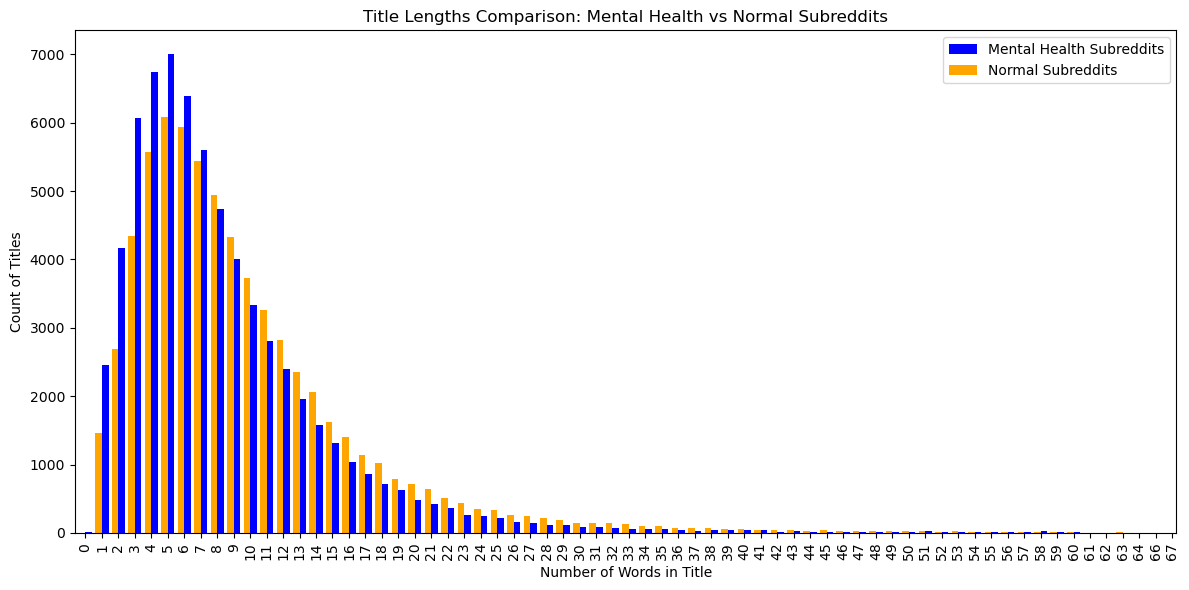

In [302]:
mental_health_counts = mentalhealth['title_length'].value_counts().sort_index()
normal_counts = normal['title_length'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
mental_health_counts.plot(kind='bar', width=0.4, position=0, label='Mental Health Subreddits', color='blue')
normal_counts.plot(kind='bar', width=0.4, position=1, label='Normal Subreddits', color='orange')
plt.title('Title Lengths Comparison: Mental Health vs Normal Subreddits')
plt.xlabel('Number of Words in Title')
plt.ylabel('Count of Titles')
plt.legend()
plt.tight_layout()
plt.show()

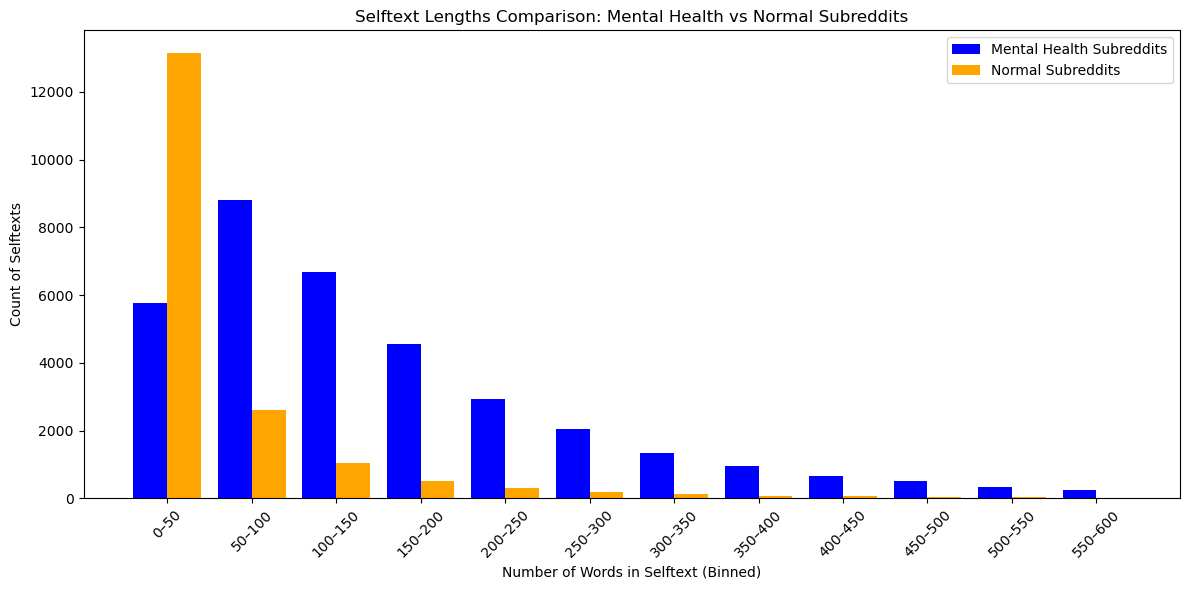

In [303]:
bins = np.arange(0, 650, 50)
mentalhealth['length_bin'] = pd.cut(mentalhealth['selftext_length'], bins=bins)
normal['length_bin'] = pd.cut(normal['selftext_length'], bins=bins)
mh_counts = mentalhealth['length_bin'].value_counts().sort_index()
normal_counts = normal['length_bin'].value_counts().sort_index()
x = np.arange(len(mh_counts))
width = 0.4
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, mh_counts.values, width=width, label='Mental Health Subreddits', color='blue')
plt.bar(x + width/2, normal_counts.values, width=width, label='Normal Subreddits', color='orange')
plt.xticks(x, [f'{int(interval.left)}–{int(interval.right)}' for interval in mh_counts.index], rotation=45)
plt.xlabel('Number of Words in Selftext (Binned)')
plt.ylabel('Count of Selftexts')
plt.title('Selftext Lengths Comparison: Mental Health vs Normal Subreddits')
plt.legend()
plt.tight_layout()
plt.show()


In [259]:
print("Mental Health Subreddits Statistics:")
print(mentalhealth['title_length'].describe())
print(mentalhealth['selftext_length'].describe())
print("Number of posts without selftext in Mental Health Subreddits:")
print(mentalhealth[mentalhealth['selftext'] == ''].shape[0])

print("Normal Subreddits Statistics:")
print(normal['title_length'].describe())
print(normal['selftext_length'].describe())
print("Number of posts without selftext in Normal Subreddits:")
print(normal[normal['selftext'] == ''].shape[0])

Mental Health Subreddits Statistics:
count    67349.000000
mean         8.293085
std          6.569345
min          0.000000
25%          4.000000
50%          7.000000
75%         11.000000
max         65.000000
Name: title_length, dtype: float64
count    67349.000000
mean        92.801170
std        161.631039
min          0.000000
25%          0.000000
50%         24.000000
75%        132.000000
max       5710.000000
Name: selftext_length, dtype: float64
Number of posts without selftext in Mental Health Subreddits:
31448
Normal Subreddits Statistics:
count    102167.000000
mean          9.605156
std           7.199867
min           0.000000
25%           5.000000
50%           8.000000
75%          12.000000
max          67.000000
Name: title_length, dtype: float64
count    102167.000000
mean         12.925769
std          52.259955
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max        2759.000000
Name: selftext_length, dtype: float64

Empty body in mental health: 31448
Empty body in normal: 74054


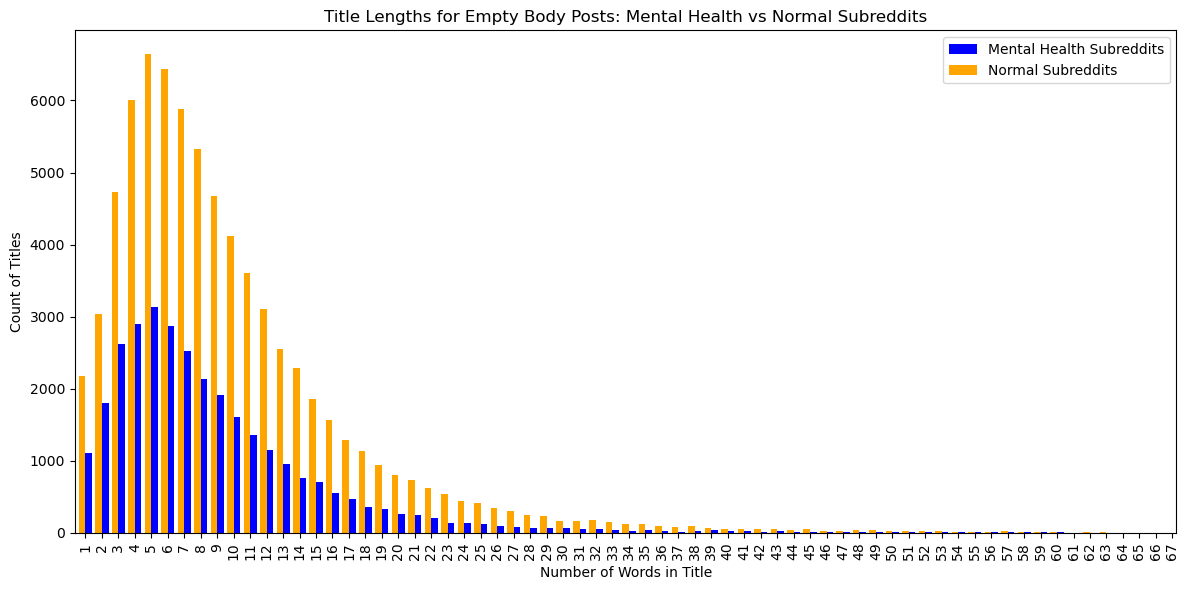

In [260]:
empty_body_mentalhealth = mentalhealth[(mentalhealth['title'] != '') & (mentalhealth['selftext'] == '')]
empty_body_normal = normal[(normal['title'] != '') & (normal['selftext'] == '')]
print(f"Empty body in mental health: {len(empty_body_mentalhealth)}")
print(f"Empty body in normal: {len(empty_body_normal)}")
# Plot title lengths for empty body posts in mental health and normal subreddits
plt.figure(figsize=(12, 6))
empty_body_mentalhealth['title_length'].value_counts().sort_index().plot(
    kind='bar', width=0.4, position=0, label='Mental Health Subreddits', color='blue')
empty_body_normal['title_length'].value_counts().sort_index().plot(
    kind='bar', width=0.4, position=1, label='Normal Subreddits', color='orange')
plt.title('Title Lengths for Empty Body Posts: Mental Health vs Normal Subreddits')
plt.xlabel('Number of Words in Title')
plt.ylabel('Count of Titles')
plt.legend()
plt.tight_layout()
plt.show()

In [306]:
mentalhealth['label'] = '1'
normal['label'] = '0'
data = pd.concat([mentalhealth, normal])
data = data[['title', 'selftext', 'label']]
data.to_csv('../train/expanded_full.csv', index=False)